# Food Price Data

https://www.bls.gov/charts/consumer-price-index/consumer-price-index-average-price-data.htm

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import seaborn as sns
# set display mode to retina
%config InlineBackend.figure_format = 'retina'
#suppress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
path = r'data/bls_food_prices.xlsx'
df = pd.read_excel(path, index_col=0)
df = df.fillna(df.mean())
df.head()

,"Bananas, per lb.","Oranges, Navel, per lb.","Bread, white, pan, per lb.","Tomatoes, field grown, per lb.","Chicken, fresh, whole, per lb.",Electricity per KWH,"Eggs, grade A, large, per doz.","Gasoline, unleaded regular, per gallon","Ground chuck, 100% beef, per lb.",Utility (piped) gas per therm,"Milk, fresh, whole, fortified, per gal."
Month,,,,,,,,,,,
2005-03-01,0.507,0.783000,1.002,1.548,1.061,0.094,1.132,2.065,2.519,1.096,3.226
2005-04-01,0.503,0.816000,1.004,1.710,1.070,0.095,1.164,2.283,2.504,1.158,3.225
2005-05-01,0.497,0.899000,1.086,1.911,1.052,0.097,1.185,2.216,2.572,1.152,3.207
2005-06-01,0.493,1.012000,1.090,1.655,1.075,0.104,1.139,2.176,2.542,1.124,3.122
2005-07-01,0.494,1.271075,1.067,1.607,1.067,0.105,1.165,2.316,2.541,1.168,3.090


## 1. The Inflation Tale: How Everyday Food Prices Have Shifted Over Time

In [3]:
melt_df = (df.reset_index()
           .melt(id_vars='Month', var_name='food', value_name='price')
           )
melt_df.sample(5)

,Month,food,price
2233,2010-07-01,Utility (piped) gas per therm,1.111
2044,2014-11-01,"Ground chuck, 100% beef, per lb.",4.260
1462,2006-07-01,"Eggs, grade A, large, per doz.",1.213
738,2006-06-01,"Tomatoes, field grown, per lb.",1.457
235,2024-10-01,"Bananas, per lb.",0.619


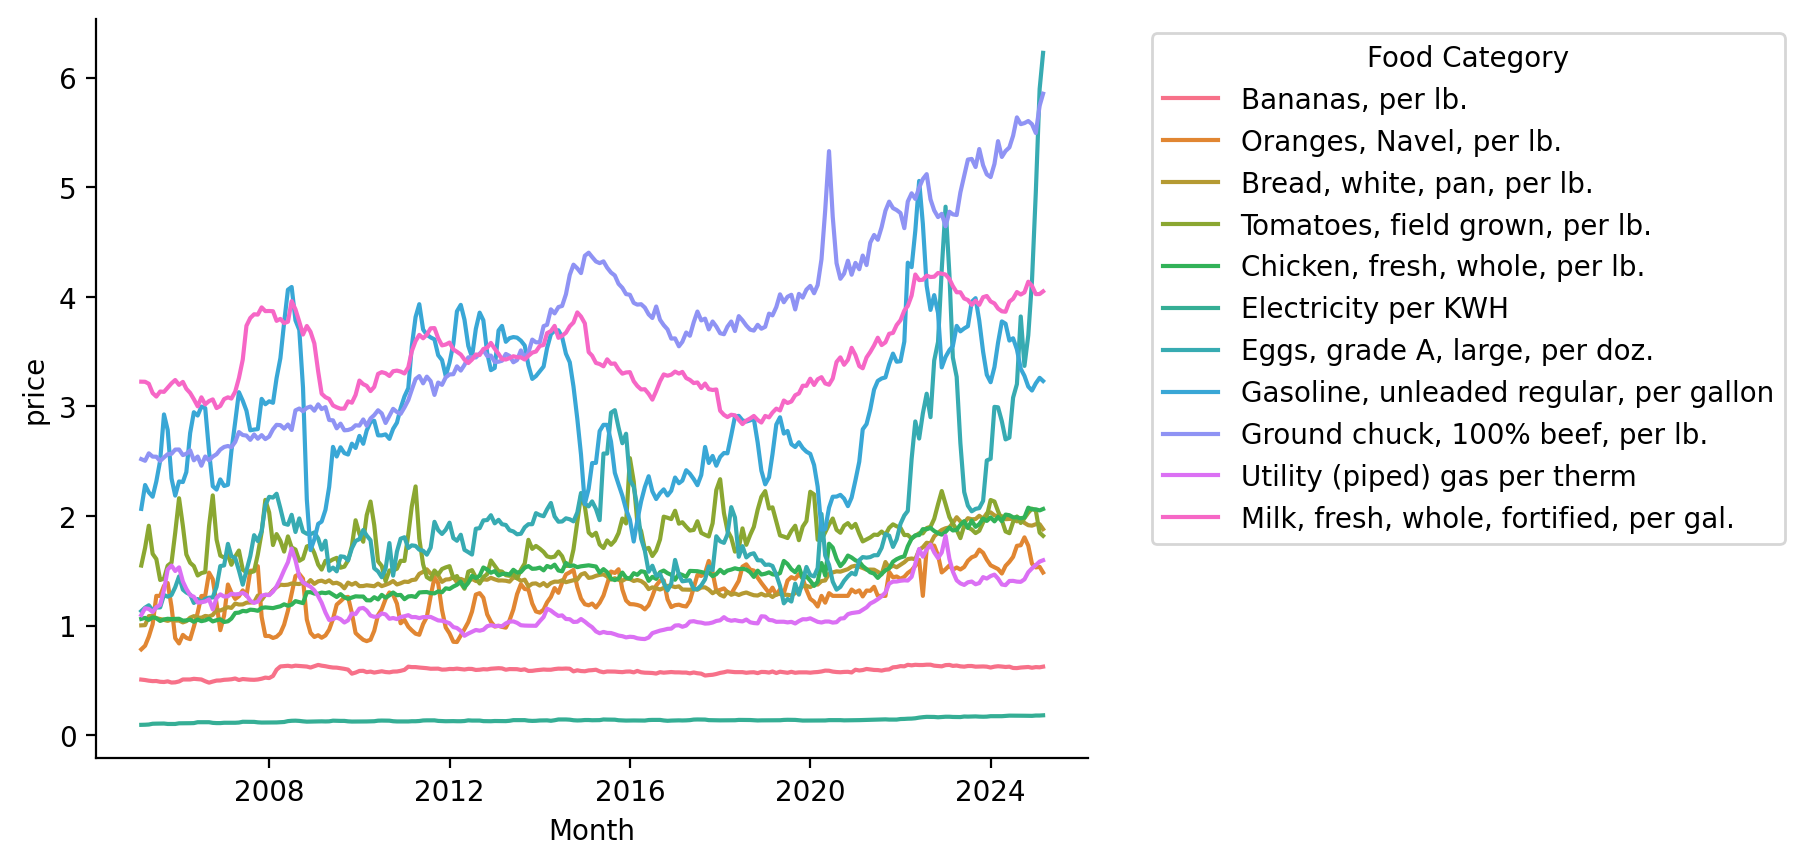

In [4]:
sns.lineplot(data=melt_df, 
             x='Month', 
             y='price', 
             hue='food')

plt.legend(title='Food Category', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')

sns.despine()

### Enhancing Figure

In [5]:
px.line(data_frame=melt_df, 
        x='Month', 
        y='price', 
        color='food', 
        title='Food Prices Over Time',
        template = 'plotly_white',
        )


### Advanced Line Plot

In [6]:
fig = px.line(
    data_frame=melt_df, 
    x='Month', 
    y='price', 
    color='food', 
    title='Food Prices Over Time with Highlights',
    template='plotly_white'
)

# # Add a rectangle to highlight the Great Recession (2008-2009)
fig.add_shape(
    type="rect",
    x0="2007-12-01", x1="2009-06-30",
    y0=0, y1=melt_df['price'].max(),
    fillcolor="red",
    opacity=0.2,
    layer="below",
    line_width=0,
)

# # Add a rectangle to highlight the COVID-19 pandemic (2020-2023)
fig.add_shape(
    type="rect",
    x0="2020-03-11", x1="2023-05-31",
    y0=0, y1=melt_df['price'].max(),
    fillcolor="blue",
    opacity=0.2,
    layer="below",
    line_width=0,
)

# # Add annotations for the highlighted periods
fig.add_annotation(
    x="2008-06-01",
    y=melt_df['price'].max() * 0.9,
    text="Great Recession",
    showarrow=False,
    font=dict(color="red", size=12)
)

fig.add_annotation(
    x="2021-06-01",
    y=melt_df['price'].max() * 0.9,
    text="COVID-19 Pandemic",
    showarrow=False,
    font=dict(color="blue", size=12)
)

# # Customize the layout for better readability
fig.update_layout(
    title_font=dict(size=20),
    xaxis_title="Month",
    yaxis_title="Price (USD)",
    legend_title="Food Category",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.9,
        xanchor="center",
        x=0.5
    )
)

fig.show()

## 2. Monthly Volatility

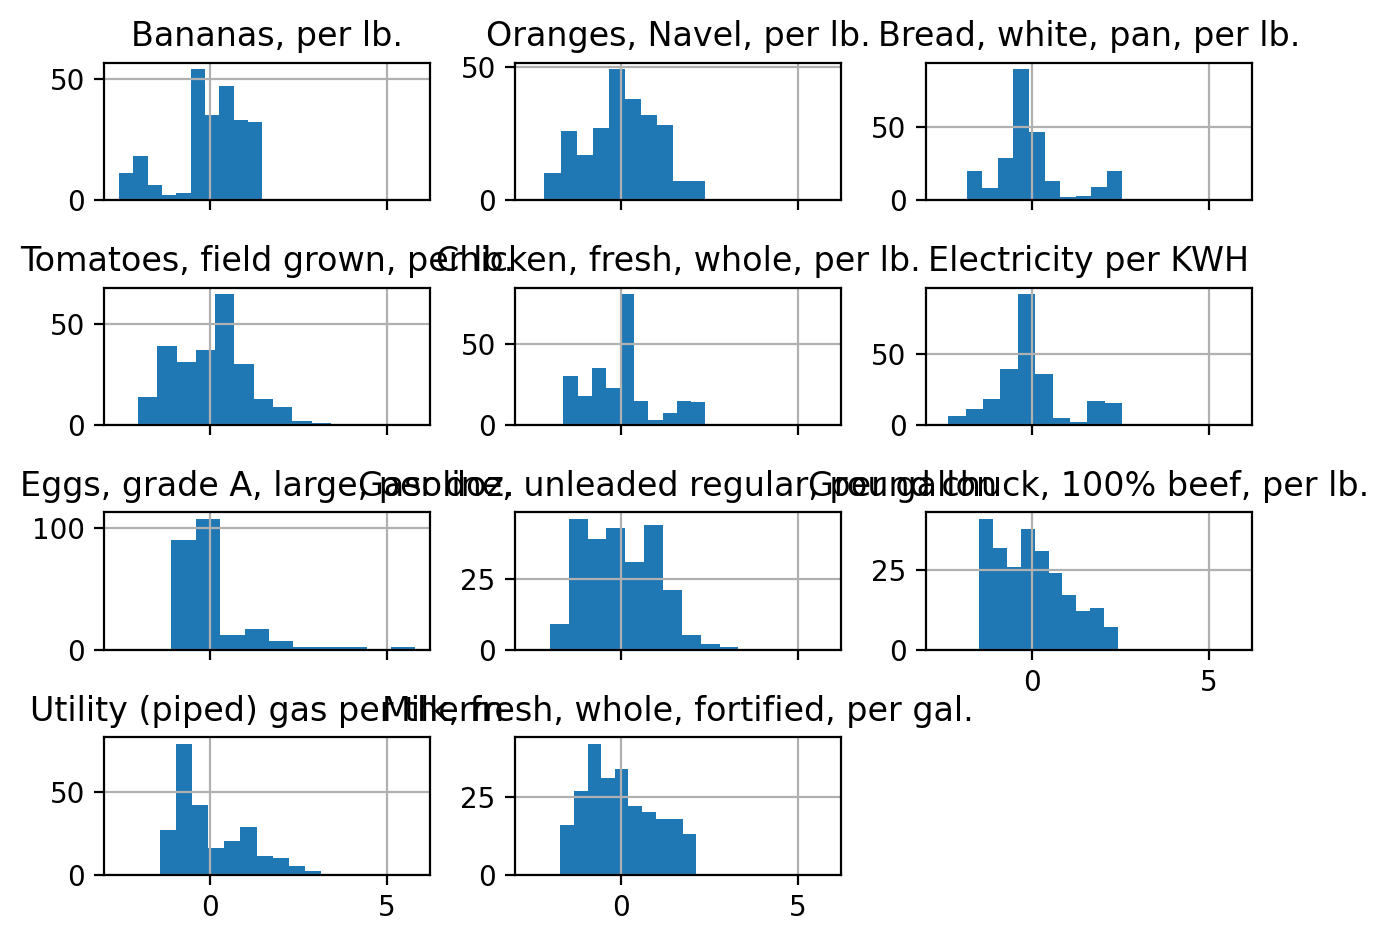

In [7]:
((df-df.mean())/df.std()).hist(sharex=True)
plt.tight_layout()

In [8]:
z_df = ((df-df.mean())/df.std()).T
z_df.columns = pd.to_datetime(z_df.columns).strftime('%Y-%m')
z_df = z_df.T
z_df.head()

,"Bananas, per lb.","Oranges, Navel, per lb.","Bread, white, pan, per lb.","Tomatoes, field grown, per lb.","Chicken, fresh, whole, per lb.",Electricity per KWH,"Eggs, grade A, large, per doz.","Gasoline, unleaded regular, per gallon","Ground chuck, 100% beef, per lb.",Utility (piped) gas per therm,"Milk, fresh, whole, fortified, per gal."
Month,,,,,,,,,,,
2005-03,-1.886219,-2.165360e+00,-1.840000,-1.074575,-1.521160,-2.367673,-1.098272,-1.417154,-1.417149,-0.367580,-0.636335
2005-04,-1.984966,-2.018955e+00,-1.831455,-0.333155,-1.486599,-2.311009,-1.054942,-1.071909,-1.434474,-0.067516,-0.639126
2005-05,-2.133085,-1.650722e+00,-1.481112,0.586756,-1.555721,-2.197681,-1.026506,-1.178016,-1.355936,-0.096554,-0.689366
2005-06,-2.231831,-1.149394e+00,-1.464022,-0.584871,-1.467398,-1.801031,-1.088794,-1.241364,-1.390585,-0.232067,-0.926609
2005-07,-2.207145,-9.851081e-16,-1.562289,-0.804551,-1.498119,-1.744366,-1.053588,-1.019647,-1.391740,-0.019118,-1.015924


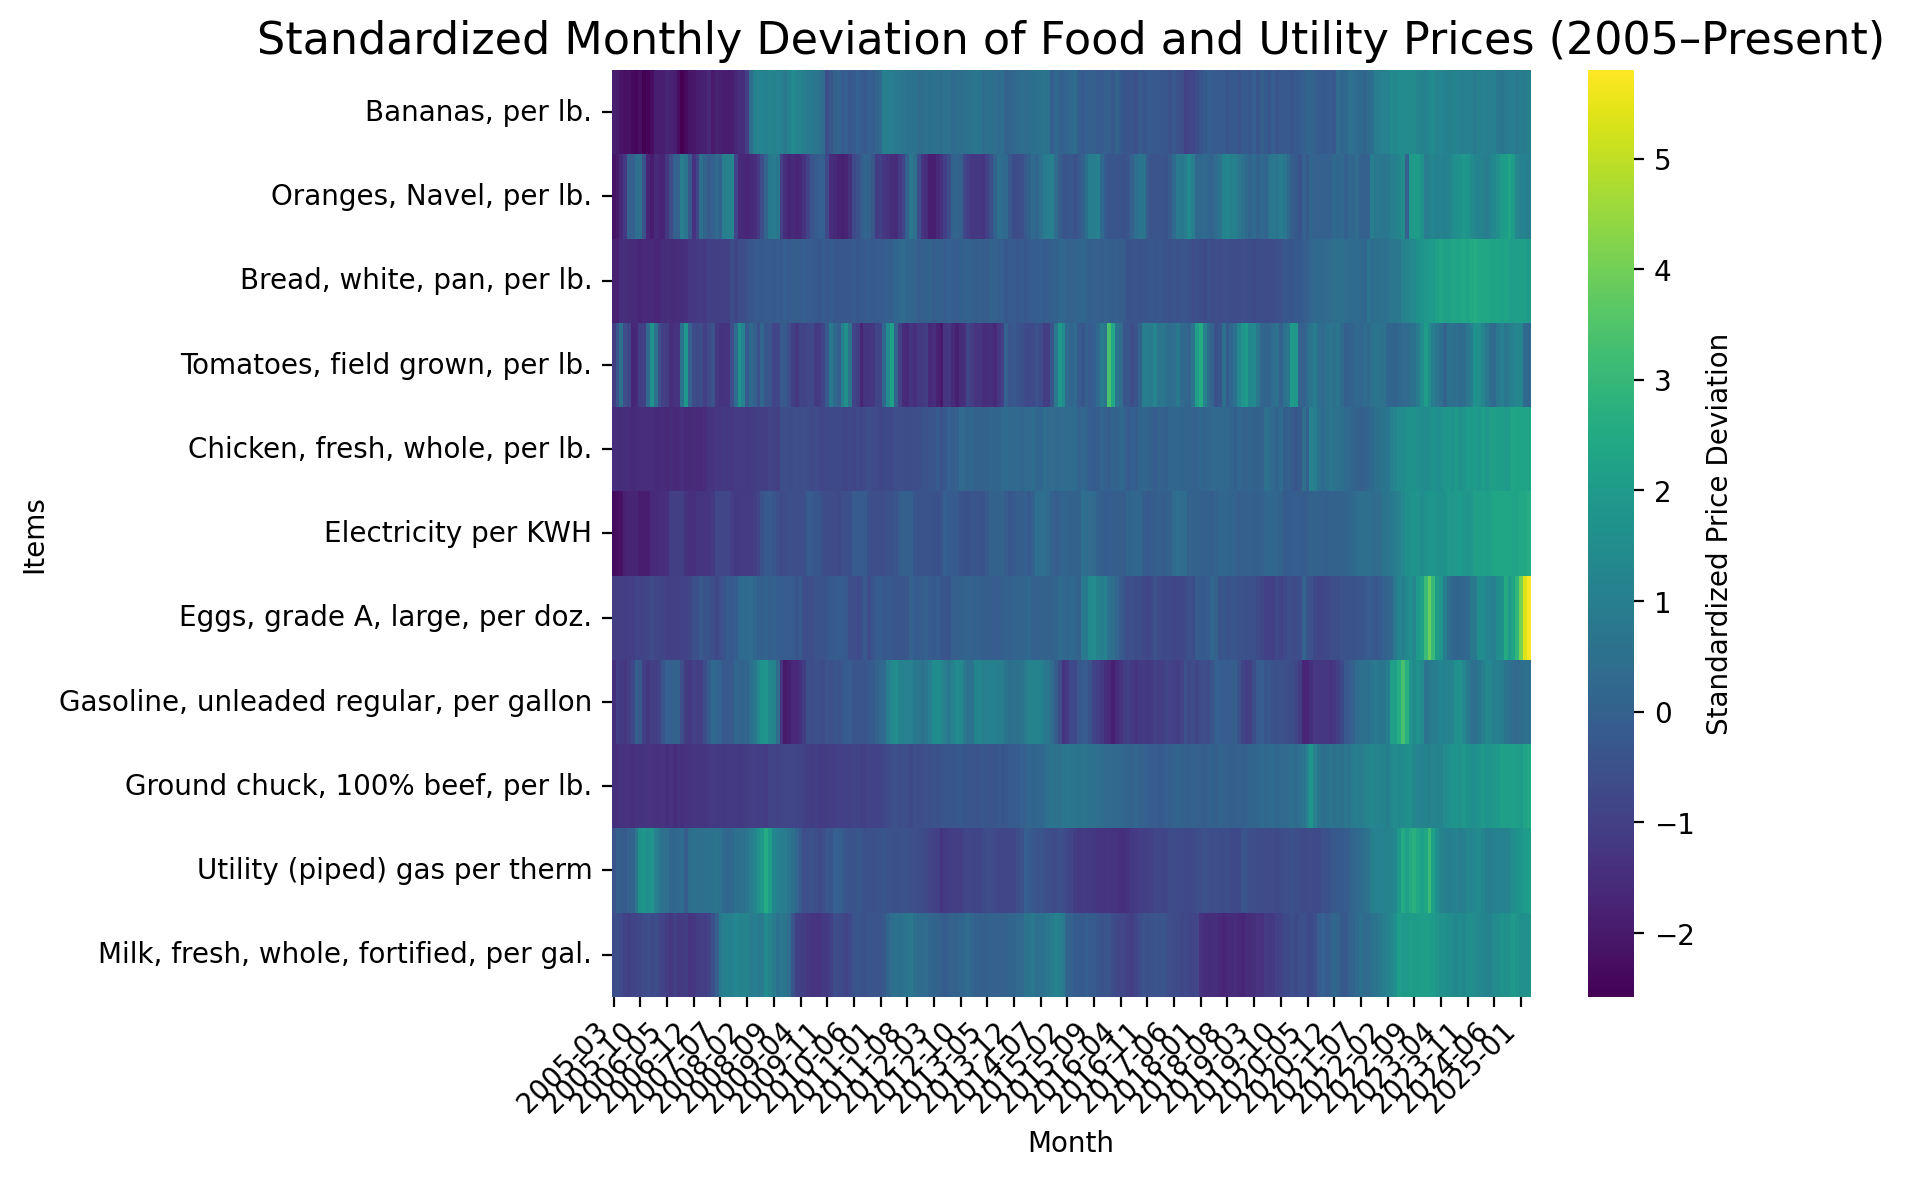

In [9]:
# Heatmap code snippet
plt.figure(figsize=(9, 6))
sns.heatmap(z_df.T, cmap='viridis', 
                 cbar_kws={'label': 'Standardized Price Deviation'}, 
                 linewidths=0.0)


plt.xticks(rotation=45, ha='right')

plt.title('Standardized Monthly Deviation of Food and Utility Prices (2005–Present)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Items')
plt.tight_layout()
plt.show() 